# Small first-shell vs second-shell AE check

This notebook compares the simple shallow-AE latent representations for two invariant local-neighbourhood inputs:

- `radii`: sorted central-particle-to-neighbour distances.
- `pairwise_dist`: sorted all-pairwise distances after adding the central particle at `(0, 0, 0)`. This includes the radii implicitly.

Both inputs are evaluated for the first-shell and second-shell files on the same 3-class task: `fcc` vs `hcp` vs `liquid`.


In [1]:
SKIP_AE = True
SKIP_EGNN_NORMAL = True
SKIP_EGNN_QL = False

In [2]:
# Imports
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


In [3]:
# Configuration
PHASES = ["fcc", "hcp", "liquid"]
LABEL_MAP = {"fcc": 0, "hcp": 1, "liquid": 2}
LABEL_NAMES = {0: "fcc", 1: "hcp", 2: "liquid"}
LABEL_COLORS = {0: "tab:blue", 1: "tab:orange", 2: "tab:green"}

SHELL_FILES = {
    "first_shell": "particle_data.npz",
    "second_shell": "particle_data_second_shell.npz",
}
SHELL_ORDER = ["first_shell", "second_shell"]
SHELL_LABELS = {
    "first_shell": "First shell",
    "second_shell": "Second shell",
}

FEATURE_KINDS = ["radii", "pairwise_dist"]
FEATURE_LABELS = {
    "radii": "Distances (radii)",
    "pairwise_dist": "Pairwise distances",
}

# Keep this first pass intentionally small. Increase after the pipeline looks right.
MAX_SAMPLES_PER_PHASE = 6000
EPOCHS = 20
BATCH_SIZE = 512
LR = 1e-3
WEIGHT_DECAY = 1e-4
LATENT_DIM = 8
SEED = 42

# Plotting: classifier scores use the full latent. This controls only the 2D display.
VIS_METHOD = "tsne"  # "tsne", "umap", "pca", or "latent" if LATENT_DIM == 2
MAX_VIS_SAMPLES_PER_PHASE = 1000
TSNE_PERPLEXITY = 30
UMAP_N_NEIGHBORS = 30
UMAP_MIN_DIST = 0.12

SCATTER_S = 10
SCATTER_ALPHA = 0.55
LEGEND_MARKERSCALE = 3.5
LEGEND_FONTSIZE = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_DIR_CANDIDATES = [
    Path("."),
    Path("autoencode_statmech/lammps/LJ/statistically_independent_samples/statistically_independent_samples"),
]
DATA_DIR = next(
    (p for p in DATA_DIR_CANDIDATES if all((p / phase / SHELL_FILES["second_shell"]).exists() for phase in PHASES)),
    None,
)
if DATA_DIR is None:
    raise FileNotFoundError("Could not find phase directories containing particle_data_second_shell.npz")

np.random.seed(SEED)
torch.manual_seed(SEED)
print("DATA_DIR:", DATA_DIR.resolve())
print("device:", DEVICE)


DATA_DIR: /home/jhausberger/Masterthesis/Repos/autoencode_statmech/lammps/LJ/statistically_independent_samples/statistically_independent_samples
device: cpu


## 1) Load and sort shell data

First-shell files have 12 neighbours; second-shell files have 18. Distances are sorted and `vec_dist` is reordered consistently before building either input type.


In [4]:
def scalar_from_npz(arr, key, default=None):
    if key not in arr.files:
        return default
    value = np.asarray(arr[key])
    return value.item() if value.shape == () else value.tolist()


def load_particle_data(npz_path):
    arr = np.load(npz_path, allow_pickle=True)
    nn = scalar_from_npz(arr, "nn")
    descriptor_nn = scalar_from_npz(arr, "descriptor_nn", nn)
    out = {
        "dist": arr["dist"].astype(np.float32),
        "ql": arr["ql"].astype(np.float32),
        "meta": {
            "nn": nn,
            "descriptor_nn": descriptor_nn,
            "n_pick": scalar_from_npz(arr, "n_pick"),
        },
    }
    if "picked_ids" in arr.files:
        out["picked_ids"] = arr["picked_ids"].astype(np.int32)
    if "frame_indices" in arr.files:
        out["frame_indices"] = arr["frame_indices"].astype(np.int32)

    vec = arr["vec_dist"]
    if vec.ndim == 3 and vec.shape[2] == 3:
        out["vec_dist"] = vec.astype(np.float32)
    elif vec.ndim == 2 and vec.shape[1] % 3 == 0:
        out["vec_dist"] = vec.reshape(vec.shape[0], vec.shape[1] // 3, 3).astype(np.float32)
    else:
        raise ValueError(f"Unexpected vec_dist shape in {npz_path}: {vec.shape}")
    return out


def sort_neighbour_arrays(data_by_phase):
    for data in data_by_phase.values():
        order = np.argsort(data["dist"], axis=1)
        data["dist"] = np.take_along_axis(data["dist"], order, axis=1)
        data["vec_dist"] = np.take_along_axis(data["vec_dist"], order[:, :, None], axis=1)


def load_shell(shell_name):
    filename = SHELL_FILES[shell_name]
    data_by_phase = {}
    for phase in PHASES:
        npz_path = DATA_DIR / phase / filename
        if not npz_path.exists():
            raise FileNotFoundError(npz_path)
        data_by_phase[phase] = load_particle_data(npz_path)
    sort_neighbour_arrays(data_by_phase)
    return data_by_phase


def summarize_shell(data_by_phase, shell_name):
    rows = []
    for phase, data in data_by_phase.items():
        n_neigh = data["dist"].shape[1]
        rows.append({
            "shell": shell_name,
            "phase": phase,
            "n_samples": data["dist"].shape[0],
            "n_neighbours": n_neigh,
            "radii_dim": n_neigh,
            "pairwise_dist_dim": (n_neigh + 1) * n_neigh // 2,
            "nn_metadata": data["meta"].get("nn"),
            "descriptor_nn": data["meta"].get("descriptor_nn"),
            "dist_shape": str(data["dist"].shape),
            "vec_dist_shape": str(data["vec_dist"].shape),
            "ql_shape": str(data["ql"].shape),
        })
    return pd.DataFrame(rows)



def shell_consistency_report(shell_data):
    rows = []
    first = shell_data["first_shell"]
    second = shell_data["second_shell"]
    for phase in PHASES:
        a = first[phase]
        b = second[phase]
        rows.append({
            "phase": phase,
            "same_frame_indices": np.array_equal(a.get("frame_indices"), b.get("frame_indices")),
            "same_picked_ids": np.array_equal(a.get("picked_ids"), b.get("picked_ids")),
            "same_ql_targets": np.allclose(a["ql"], b["ql"]),
            "ql_abs_mean_diff": float(np.mean(np.abs(a["ql"] - b["ql"]))),
            "first_descriptor_nn": a["meta"].get("descriptor_nn"),
            "second_descriptor_nn": b["meta"].get("descriptor_nn"),
        })
    return pd.DataFrame(rows)

shell_data = {shell_name: load_shell(shell_name) for shell_name in SHELL_ORDER}
display(pd.concat(
    [summarize_shell(shell_data[shell_name], shell_name) for shell_name in SHELL_ORDER],
    ignore_index=True,
))
display(shell_consistency_report(shell_data))


,shell,phase,n_samples,n_neighbours,radii_dim,pairwise_dist_dim,nn_metadata,descriptor_nn,dist_shape,vec_dist_shape,ql_shape
0,first_shell,fcc,180300,12,12,78,12,12,"(180300, 12)","(180300, 12, 3)","(180300, 20)"
1,first_shell,hcp,180300,12,12,78,12,12,"(180300, 12)","(180300, 12, 3)","(180300, 20)"
2,first_shell,liquid,90300,12,12,78,12,12,"(90300, 12)","(90300, 12, 3)","(90300, 20)"
3,second_shell,fcc,180300,18,18,171,18,12,"(180300, 18)","(180300, 18, 3)","(180300, 20)"
4,second_shell,hcp,180300,18,18,171,18,12,"(180300, 18)","(180300, 18, 3)","(180300, 20)"
5,second_shell,liquid,90300,18,18,171,18,12,"(90300, 18)","(90300, 18, 3)","(90300, 20)"


,phase,same_frame_indices,same_picked_ids,same_ql_targets,ql_abs_mean_diff,first_descriptor_nn,second_descriptor_nn
0,fcc,True,True,True,0.0,12,12
1,hcp,True,True,True,0.0,12,12
2,liquid,True,True,True,0.0,12,12


## 2) Feature and autoencoder helpers

`radii` uses the sorted central-particle distances directly. `pairwise_dist` now adds the central particle at `(0, 0, 0)`, computes all pairwise distances over `central + neighbours`, and sorts those distances per particle. This makes the radii part of the pairwise signature and keeps the input invariant to global rotation, translation, and neighbour ordering.

The previous one-layer `input -> 2D ReLU -> input` AE can collapse for the larger pairwise input. The model below keeps the same reconstruction objective but uses a small capacity-scaled MLP and a linear latent space. Classification is done on the full latent vector; the 2D plot is a visualization projection of that latent.


In [5]:
class ShallowAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=LATENT_DIM):
        super().__init__()
        hidden_dim = max(32, min(256, input_dim * 2))
        mid_dim = max(16, hidden_dim // 2)

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, mid_dim),
            nn.SiLU(),
            nn.Linear(mid_dim, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, mid_dim),
            nn.SiLU(),
            nn.Linear(mid_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

    def encode(self, x):
        return self.encoder(x)


def with_central_point(vec):
    central = np.zeros((vec.shape[0], 1, 3), dtype=vec.dtype)
    return np.concatenate([central, vec], axis=1)


def pairwise_distance_features(vec):
    points = with_central_point(vec)
    diffs = points[:, :, None, :] - points[:, None, :, :]
    dist = np.linalg.norm(diffs, axis=-1)
    upper = np.triu_indices(points.shape[1], k=1)
    pairwise = dist[:, upper[0], upper[1]]
    return np.sort(pairwise, axis=1).astype(np.float32)


def feature_array(data, feature_kind, idx):
    if feature_kind == "radii":
        return data["dist"][idx].astype(np.float32)
    if feature_kind == "pairwise_dist":
        return pairwise_distance_features(data["vec_dist"][idx])
    raise KeyError(f"Unknown feature kind: {feature_kind}")


def make_ae_data(data_by_phase, feature_kind, selected_phases=PHASES, max_samples_per_phase=MAX_SAMPLES_PER_PHASE, seed=SEED):
    rng = np.random.default_rng(seed)
    Xs, ys = [], []
    for phase in selected_phases:
        n = data_by_phase[phase]["dist"].shape[0]
        if max_samples_per_phase is not None and n > max_samples_per_phase:
            idx = rng.choice(n, size=max_samples_per_phase, replace=False)
        else:
            idx = np.arange(n)

        X = feature_array(data_by_phase[phase], feature_kind, idx)
        y = np.full(X.shape[0], LABEL_MAP[phase], dtype=int)
        Xs.append(X.astype(np.float32))
        ys.append(y)

    X = np.concatenate(Xs, axis=0)
    y = np.concatenate(ys, axis=0)
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X).astype(np.float32)
    return X_scaled, y, scaler


def train_shallow_ae(
    X,
    y,
    latent_dim=LATENT_DIM,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    seed=SEED,
):
    torch.manual_seed(seed)
    X_train, X_val, _, _ = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y, shuffle=True
    )
    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_train), torch.tensor(X_train)),
        batch_size=batch_size,
        shuffle=True,
    )
    val_loader = DataLoader(
        TensorDataset(torch.tensor(X_val), torch.tensor(X_val)),
        batch_size=batch_size,
        shuffle=False,
    )

    model = ShallowAutoencoder(X.shape[1], latent_dim=latent_dim).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()
    hist = {"loss": [], "val_loss": []}

    for _ in range(epochs):
        model.train()
        train_loss = 0.0
        for xb, target in train_loader:
            xb = xb.to(DEVICE)
            target = target.to(DEVICE)
            opt.zero_grad()
            loss = criterion(model(xb), target)
            loss.backward()
            opt.step()
            train_loss += loss.item() * xb.size(0)
        hist["loss"].append(train_loss / len(train_loader.dataset))

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, target in val_loader:
                xb = xb.to(DEVICE)
                target = target.to(DEVICE)
                val_loss += criterion(model(xb), target).item() * xb.size(0)
        hist["val_loss"].append(val_loss / len(val_loader.dataset))

    model.eval()
    with torch.no_grad():
        Z = model.encode(torch.tensor(X, dtype=torch.float32).to(DEVICE)).cpu().numpy()
    return model, hist, Z


def score_latent_classifier(Z, y, seed=SEED):
    X_train, X_test, y_train, y_test = train_test_split(
        Z, y, test_size=0.2, random_state=seed, stratify=y, shuffle=True
    )
    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000, class_weight="balanced"),
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    labels = sorted(np.unique(y))
    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, labels=labels, average="macro"),
        "y_test": y_test,
        "y_pred": y_pred,
        "labels": labels,
        "probe": clf,
    }


def latent_diagnostics(Z):
    return {
        "latent_std_mean": float(np.mean(np.std(Z, axis=0))),
        "latent_std_min": float(np.min(np.std(Z, axis=0))),
        "latent_abs_mean": float(np.mean(np.abs(Z))),
    }


## 3) Run compact 3-class AE experiments

In [6]:
def run_ae_suite(shell_data):
    rows = []
    artifacts = {}
    for shell_name in SHELL_ORDER:
        for feature_kind in FEATURE_KINDS:
            print(f"Training {SHELL_LABELS[shell_name]} | {FEATURE_LABELS[feature_kind]}")
            X, y, scaler = make_ae_data(shell_data[shell_name], feature_kind, PHASES)
            model, hist, Z = train_shallow_ae(X, y)
            scores = score_latent_classifier(Z, y)
            diag = latent_diagnostics(Z)

            rows.append({
                "shell": shell_name,
                "input_type": feature_kind,
                "n_samples": len(y),
                "input_dim": X.shape[1],
                "latent_dim": Z.shape[1],
                "final_val_mse": hist["val_loss"][-1],
                "latent_accuracy": scores["accuracy"],
                "latent_balanced_accuracy": scores["balanced_accuracy"],
                "latent_macro_f1": scores["macro_f1"],
                **diag,
            })
            artifacts[(shell_name, feature_kind)] = {
                "X": X,
                "y": y,
                "scaler": scaler,
                "model": model,
                "history": hist,
                "Z": Z,
                "scores": scores,
                "diagnostics": diag,
            }
    return pd.DataFrame(rows), artifacts

if not SKIP_AE:
    scores_df, artifacts = run_ae_suite(shell_data)
    display(scores_df.sort_values(["input_type", "shell"]).round(4))


## 4) Latent representation comparison

Rows are input types; columns are first shell vs second shell. Classification uses the full latent vector. The plot projects that latent to 2D with `VIS_METHOD`; t-SNE remains the default projection. The 2D projection should not be interpreted as the actual classifier input.


In [7]:
def sample_for_visualization(Z, y, max_samples_per_phase=MAX_VIS_SAMPLES_PER_PHASE, seed=SEED):
    rng = np.random.default_rng(seed)
    keep = []
    for lab in sorted(np.unique(y)):
        idx = np.flatnonzero(y == lab)
        if len(idx) > max_samples_per_phase:
            idx = rng.choice(idx, size=max_samples_per_phase, replace=False)
        keep.append(idx)
    keep = np.concatenate(keep)
    return Z[keep], y[keep]


def umap_available():
    try:
        import umap  # noqa: F401
        return True
    except ImportError:
        print("UMAP skipped: install umap-learn in this notebook kernel to enable additional UMAP plots.")
        return False


UMAP_AVAILABLE = umap_available()


def project_latent_for_plot(Z, y, method=VIS_METHOD, seed=SEED):
    Z_vis, y_vis = sample_for_visualization(Z, y)
    if method == "latent" and Z_vis.shape[1] == 2:
        return Z_vis, y_vis, "latent"
    if method == "umap":
        try:
            import umap
            n_neighbors = min(UMAP_N_NEIGHBORS, max(2, len(y_vis) - 1))
            Z_plot = umap.UMAP(
                n_components=2,
                n_neighbors=n_neighbors,
                min_dist=UMAP_MIN_DIST,
                metric="euclidean",
                random_state=seed,
            ).fit_transform(Z_vis)
            return Z_plot, y_vis, "UMAP(latent)"
        except ImportError:
            print("umap-learn is not installed; falling back to PCA for this plot.")
    if method == "tsne":
        perplexity = min(TSNE_PERPLEXITY, max(5, (len(y_vis) - 1) // 3))
        Z_plot = TSNE(
            n_components=2,
            perplexity=perplexity,
            init="pca",
            learning_rate="auto",
            random_state=seed,
        ).fit_transform(Z_vis)
        return Z_plot, y_vis, "t-SNE(latent)"
    Z_plot = PCA(n_components=2, random_state=seed).fit_transform(Z_vis)
    return Z_plot, y_vis, "PCA(latent)"


def plot_latent_comparison(artifacts, method=VIS_METHOD):
    fig, axes = plt.subplots(len(FEATURE_KINDS), len(SHELL_ORDER), figsize=(12, 8.5), squeeze=False)
    for row, feature_kind in enumerate(FEATURE_KINDS):
        for col, shell_name in enumerate(SHELL_ORDER):
            ax = axes[row, col]
            art = artifacts[(shell_name, feature_kind)]
            Z_plot, y_plot, projection_label = project_latent_for_plot(art["Z"], art["y"], method=method)
            for phase in PHASES:
                lab = LABEL_MAP[phase]
                mask = y_plot == lab
                ax.scatter(
                    Z_plot[mask, 0],
                    Z_plot[mask, 1],
                    s=SCATTER_S,
                    alpha=SCATTER_ALPHA,
                    color=LABEL_COLORS[lab],
                    label=phase,
                )
            score = art["scores"]["balanced_accuracy"]
            ax.set_title(f"{SHELL_LABELS[shell_name]} | {FEATURE_LABELS[feature_kind]} | bal. acc={score:.3f}")
            ax.set_xlabel(projection_label + " 1")
            ax.set_ylabel(projection_label + " 2")
            ax.grid(alpha=0.2)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=len(PHASES),
        bbox_to_anchor=(0.5, 1.02),
        markerscale=LEGEND_MARKERSCALE,
        fontsize=LEGEND_FONTSIZE,
    )
    plt.tight_layout()
    plt.show()

if not SKIP_AE:
    plot_latent_comparison(artifacts, method=VIS_METHOD)
    if UMAP_AVAILABLE:
        plot_latent_comparison(artifacts, method="umap")


/home/jhausberger/.conda/envs/autoencode-statmech/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1782291062.430599   22790 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782291063.984092   22790 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 5) 3-class confusion matrices

The confusion matrices use logistic regression trained on the 2D AE latent representation. Values are normalized by true class.


In [8]:
def plot_confusion_grid(artifacts, normalize="true"):
    fig, axes = plt.subplots(len(FEATURE_KINDS), len(SHELL_ORDER), figsize=(11, 8.5), squeeze=False)
    for row, feature_kind in enumerate(FEATURE_KINDS):
        for col, shell_name in enumerate(SHELL_ORDER):
            ax = axes[row, col]
            scores = artifacts[(shell_name, feature_kind)]["scores"]
            names = [LABEL_NAMES[i] for i in scores["labels"]]
            cm = confusion_matrix(
                scores["y_test"],
                scores["y_pred"],
                labels=scores["labels"],
                normalize=normalize,
            )
            disp = ConfusionMatrixDisplay(cm, display_labels=names)
            disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
            ax.set_title(f"{SHELL_LABELS[shell_name]} | {FEATURE_LABELS[feature_kind]}")
            ax.grid(False)
    plt.tight_layout()
    plt.show()

if not SKIP_AE:
    plot_confusion_grid(artifacts, normalize="true")


## 6) First-shell vs second-shell deltas

Positive deltas mean the second-shell input improved the latent-space classifier under this small shared sampling budget.


In [9]:
if not SKIP_AE:
    metric_cols = ["latent_accuracy", "latent_balanced_accuracy", "latent_macro_f1", "final_val_mse"]
    wide = scores_df.pivot(index="input_type", columns="shell", values=metric_cols)
    delta = pd.DataFrame(index=wide.index)
    for metric in metric_cols:
        delta[f"delta_{metric}"] = wide[(metric, "second_shell")] - wide[(metric, "first_shell")]
    display(delta.reset_index().round(4))


## 7) Training curves

In [10]:
def plot_training_curves(artifacts):
    fig, axes = plt.subplots(len(FEATURE_KINDS), len(SHELL_ORDER), figsize=(12, 8.5), squeeze=False)
    for row, feature_kind in enumerate(FEATURE_KINDS):
        for col, shell_name in enumerate(SHELL_ORDER):
            ax = axes[row, col]
            hist = artifacts[(shell_name, feature_kind)]["history"]
            ax.plot(hist["loss"], label="train")
            ax.plot(hist["val_loss"], label="val")
            ax.set_title(f"{SHELL_LABELS[shell_name]} | {FEATURE_LABELS[feature_kind]}")
            ax.set_xlabel("epoch")
            ax.set_ylabel("MSE")
            ax.grid(alpha=0.2)
    axes[0, 0].legend()
    plt.tight_layout()
    plt.show()

if not SKIP_AE:
    plot_training_curves(artifacts)


## 8) EGNN invariant autoencoder

This section compares first-shell and second-shell neighbourhoods with an EGNN encoder.

The permutation-invariant decoder design is the important part: the encoder receives the unordered neighbour coordinate cloud, but the decoder reconstructs an invariant distance signature instead of ordered coordinates:

- sorted all-pairwise distances over `central + neighbours`

This includes the radii implicitly and avoids a point-assignment problem in the decoder while still forcing the latent vector to encode the local metric geometry. The linear probe and confusion matrices use the EGNN latent vectors; t-SNE is only used for plotting.


In [11]:
# EGNN configuration
EGNN_MAX_SAMPLES_PER_PHASE = 2000
EGNN_EPOCHS = 20
EGNN_BATCH_SIZE = 256
EGNN_LR = 1e-3
EGNN_WEIGHT_DECAY = 1e-4
EGNN_LATENT_DIM = 2
EGNN_FEAT_DIM = 48
EGNN_N_LAYERS = 2
EGNN_COORD_SCALE = 0.05
EGNN_GRAD_CLIP = 5.0
EGNN_VIS_METHOD = "tsne"  # "tsne", "umap", or "pca"
EGNN_MAX_VIS_SAMPLES_PER_PHASE = 800


In [12]:
import torch.nn.functional as F


class EGNNMLP(nn.Module):
    def __init__(self, dims, act=nn.SiLU, final_act=False):
        super().__init__()
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            if i < len(dims) - 2 or final_act:
                layers.append(act())
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class EGNNLayer(nn.Module):
    def __init__(self, feat_dim, hidden_dim=48, coord_scale=EGNN_COORD_SCALE):
        super().__init__()
        self.edge_mlp = EGNNMLP([2 * feat_dim + 1, hidden_dim, hidden_dim, hidden_dim])
        self.coord_mlp = EGNNMLP([hidden_dim, hidden_dim, 1])
        self.node_mlp = EGNNMLP([feat_dim + hidden_dim, hidden_dim, feat_dim])
        self.norm = nn.LayerNorm(feat_dim)
        self.coord_scale = coord_scale

    def forward(self, h, x, edge_index):
        row, col = edge_index
        hi = h[:, row, :]
        hj = h[:, col, :]
        rel = x[:, row, :] - x[:, col, :]
        dist2 = (rel ** 2).sum(dim=-1, keepdim=True)

        m_ij = self.edge_mlp(torch.cat([hi, hj, dist2], dim=-1))
        coord_coeff = torch.tanh(self.coord_mlp(m_ij))
        trans = rel * coord_coeff
        agg_trans = torch.zeros(x.shape[0], x.shape[1], 3, device=x.device, dtype=x.dtype)
        agg_trans.index_add_(1, row, trans)
        x = x + self.coord_scale * agg_trans / max(1, x.shape[1] - 1)

        agg_m = torch.zeros(h.shape[0], h.shape[1], m_ij.shape[-1], device=h.device, dtype=h.dtype)
        agg_m.index_add_(1, row, m_ij)
        agg_m = agg_m / max(1, h.shape[1] - 1)

        h = h + self.node_mlp(torch.cat([h, agg_m], dim=-1))
        return self.norm(h), x


class EGNNEncoder(nn.Module):
    def __init__(self, n_layers=EGNN_N_LAYERS, feat_dim=EGNN_FEAT_DIM, latent_dim=EGNN_LATENT_DIM):
        super().__init__()
        # Node feature is radius to the central particle; geometry enters through coordinates and dist2 messages.
        self.node_embed = nn.Sequential(nn.Linear(1, feat_dim), nn.SiLU(), nn.Linear(feat_dim, feat_dim))
        self.layers = nn.ModuleList([EGNNLayer(feat_dim, feat_dim) for _ in range(n_layers)])
        self.to_latent = EGNNMLP([2 * feat_dim, feat_dim, feat_dim, latent_dim])

    def forward(self, x, edge_index):
        radii = torch.linalg.norm(x, dim=-1, keepdim=True)
        h = self.node_embed(radii)
        for layer in self.layers:
            h, x = layer(h, x, edge_index)

        pooled_mean = h.mean(dim=1)
        pooled_max = h.max(dim=1).values
        return self.to_latent(torch.cat([pooled_mean, pooled_max], dim=-1))


class InvariantSignatureDecoder(nn.Module):
    def __init__(self, latent_dim, out_dim, hidden_dim=EGNN_FEAT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            EGNNMLP([latent_dim, hidden_dim, hidden_dim, hidden_dim, out_dim]),
            nn.Sigmoid(),
        )

    def forward(self, z):
        return self.net(z)


class InvariantEGNNAE(nn.Module):
    def __init__(self, n_points, latent_dim=EGNN_LATENT_DIM, feat_dim=EGNN_FEAT_DIM, n_layers=EGNN_N_LAYERS):
        super().__init__()
        self.n_points = n_points
        self.out_dim = n_points * (n_points - 1) // 2
        self.encoder = EGNNEncoder(n_layers=n_layers, feat_dim=feat_dim, latent_dim=latent_dim)
        self.decoder = InvariantSignatureDecoder(latent_dim, self.out_dim, hidden_dim=feat_dim)

    def encode(self, x, edge_index):
        return self.encoder(x, edge_index)

    def forward(self, x, edge_index):
        z = self.encode(x, edge_index)
        return self.decoder(z), z


def make_fully_connected_edges(n_nodes):
    row, col = [], []
    for i in range(n_nodes):
        for j in range(n_nodes):
            if i != j:
                row.append(i)
                col.append(j)
    return torch.tensor([row, col], dtype=torch.long)


def invariant_signature_torch(x):
    dmat = torch.cdist(x, x, p=2)
    upper = torch.triu_indices(x.shape[1], x.shape[1], offset=1, device=x.device)
    return torch.sort(dmat[:, upper[0], upper[1]], dim=1).values


def invariant_signature_numpy(x):
    diffs = x[:, :, None, :] - x[:, None, :, :]
    dist = np.linalg.norm(diffs, axis=-1)
    upper = np.triu_indices(x.shape[1], k=1)
    return np.sort(dist[:, upper[0], upper[1]], axis=1).astype(np.float32)


def scale_coords_by_median_radius(X):
    radii = np.linalg.norm(X, axis=-1).reshape(-1)
    scale = np.median(radii)
    if not np.isfinite(scale) or scale <= 0:
        scale = 1.0
    return (X / scale).astype(np.float32), float(scale)


def make_egnn_data(data_by_phase, max_samples_per_phase=EGNN_MAX_SAMPLES_PER_PHASE, seed=SEED):
    rng = np.random.default_rng(seed)
    Xs, ys = [], []
    for phase in PHASES:
        X = data_by_phase[phase]["vec_dist"]
        n = X.shape[0]
        if max_samples_per_phase is not None and n > max_samples_per_phase:
            idx = rng.choice(n, size=max_samples_per_phase, replace=False)
            X = X[idx]
        y = np.full(X.shape[0], LABEL_MAP[phase], dtype=int)
        Xs.append(X.astype(np.float32))
        ys.append(y)

    X = np.concatenate(Xs, axis=0)
    y = np.concatenate(ys, axis=0)
    X = with_central_point(X)
    X_scaled, coord_scale = scale_coords_by_median_radius(X)
    return X_scaled, y, coord_scale


def train_egnn_ae(X, y, epochs=EGNN_EPOCHS, batch_size=EGNN_BATCH_SIZE, seed=SEED):
    torch.manual_seed(seed)
    target_scaler = MinMaxScaler()
    target = target_scaler.fit_transform(invariant_signature_numpy(X)).astype(np.float32)

    X_train, X_val, target_train, target_val = train_test_split(
        X, target, test_size=0.2, random_state=seed, stratify=y, shuffle=True
    )
    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_train), torch.tensor(target_train)),
        batch_size=batch_size,
        shuffle=True,
    )
    val_loader = DataLoader(
        TensorDataset(torch.tensor(X_val), torch.tensor(target_val)),
        batch_size=batch_size,
        shuffle=False,
    )

    n_points = X.shape[1]
    edge_index = make_fully_connected_edges(n_points).to(DEVICE)
    model = InvariantEGNNAE(n_points=n_points).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=EGNN_LR, weight_decay=EGNN_WEIGHT_DECAY)
    hist = {"loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        total = 0.0
        for xb, target in train_loader:
            xb = xb.to(DEVICE)
            target = target.to(DEVICE)
            pred, _ = model(xb, edge_index)
            loss = F.mse_loss(pred, target)
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), EGNN_GRAD_CLIP)
            opt.step()
            total += loss.item() * xb.size(0)
        hist["loss"].append(total / len(train_loader.dataset))

        model.eval()
        total = 0.0
        with torch.no_grad():
            for xb, target in val_loader:
                xb = xb.to(DEVICE)
                target = target.to(DEVICE)
                pred, _ = model(xb, edge_index)
                total += F.mse_loss(pred, target).item() * xb.size(0)
        hist["val_loss"].append(total / len(val_loader.dataset))

        if epoch == 0 or (epoch + 1) % 5 == 0 or epoch == epochs - 1:
            print(f"epoch {epoch + 1:03d} | train={hist['loss'][-1]:.5f} | val={hist['val_loss'][-1]:.5f}")

    model.eval()
    zs = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = torch.tensor(X[i:i + batch_size], dtype=torch.float32, device=DEVICE)
            zs.append(model.encode(xb, edge_index).cpu().numpy())
    Z = np.concatenate(zs, axis=0)
    return model, hist, Z, edge_index, target_scaler


In [13]:
def run_egnn_suite(shell_data):
    rows = []
    artifacts = {}
    for shell_name in SHELL_ORDER:
        print("=" * 72)
        print(f"EGNN AE | {SHELL_LABELS[shell_name]}")
        print("=" * 72)
        X, y, coord_scale = make_egnn_data(shell_data[shell_name])
        model, hist, Z, edge_index, target_scaler = train_egnn_ae(X, y)
        scores = score_latent_classifier(Z, y)
        diag = latent_diagnostics(Z)

        rows.append({
            "shell": shell_name,
            "n_samples": len(y),
            "n_points": X.shape[1],
            "target_dim": X.shape[1] * (X.shape[1] - 1) // 2,
            "latent_dim": Z.shape[1],
            "coord_scale": coord_scale,
            "final_val_loss": hist["val_loss"][-1],
            "latent_accuracy": scores["accuracy"],
            "latent_balanced_accuracy": scores["balanced_accuracy"],
            "latent_macro_f1": scores["macro_f1"],
            **diag,
        })
        artifacts[shell_name] = {
            "X": X,
            "y": y,
            "model": model,
            "history": hist,
            "Z": Z,
            "scores": scores,
            "edge_index": edge_index,
            "coord_scale": coord_scale,
            "target_scaler": target_scaler,
        }
    return pd.DataFrame(rows), artifacts

if not SKIP_EGNN_NORMAL:
    egnn_scores_df, egnn_artifacts = run_egnn_suite(shell_data)
    display(egnn_scores_df.round(4))


## 9) EGNN latent comparison and confusion matrices

In [14]:
def sample_egnn_for_visualization(Z, y, max_samples_per_phase=EGNN_MAX_VIS_SAMPLES_PER_PHASE, seed=SEED):
    rng = np.random.default_rng(seed)
    keep = []
    for lab in sorted(np.unique(y)):
        idx = np.flatnonzero(y == lab)
        if len(idx) > max_samples_per_phase:
            idx = rng.choice(idx, size=max_samples_per_phase, replace=False)
        keep.append(idx)
    keep = np.concatenate(keep)
    return Z[keep], y[keep]


def project_egnn_latent_for_plot(Z, y, method=EGNN_VIS_METHOD, seed=SEED):
    Z_vis, y_vis = sample_egnn_for_visualization(Z, y, max_samples_per_phase=EGNN_MAX_VIS_SAMPLES_PER_PHASE, seed=seed)
    if method == "umap":
        try:
            import umap
            n_neighbors = min(UMAP_N_NEIGHBORS, max(2, len(y_vis) - 1))
            Z_plot = umap.UMAP(
                n_components=2,
                n_neighbors=n_neighbors,
                min_dist=UMAP_MIN_DIST,
                metric="euclidean",
                random_state=seed,
            ).fit_transform(Z_vis)
            return Z_plot, y_vis, "UMAP(EGNN latent)"
        except ImportError:
            print("umap-learn is not installed; falling back to PCA for this plot.")
    if method == "tsne":
        perplexity = min(TSNE_PERPLEXITY, max(5, (len(y_vis) - 1) // 3))
        Z_plot = TSNE(
            n_components=2,
            perplexity=perplexity,
            init="pca",
            learning_rate="auto",
            random_state=seed,
        ).fit_transform(Z_vis)
        return Z_plot, y_vis, "t-SNE(EGNN latent)"
    return PCA(n_components=2, random_state=seed).fit_transform(Z_vis), y_vis, "PCA(EGNN latent)"


def plot_egnn_latents(artifacts, method=EGNN_VIS_METHOD):
    fig, axes = plt.subplots(1, len(SHELL_ORDER), figsize=(12, 4.8), squeeze=False)
    for ax, shell_name in zip(axes[0], SHELL_ORDER):
        art = artifacts[shell_name]
        Z_plot, y_plot, projection_label = project_egnn_latent_for_plot(art["Z"], art["y"], method=method)
        for phase in PHASES:
            lab = LABEL_MAP[phase]
            mask = y_plot == lab
            ax.scatter(
                Z_plot[mask, 0],
                Z_plot[mask, 1],
                s=SCATTER_S,
                alpha=SCATTER_ALPHA,
                color=LABEL_COLORS[lab],
                label=phase,
            )
        score = art["scores"]["balanced_accuracy"]
        ax.set_title(f"{SHELL_LABELS[shell_name]} | EGNN AE | bal. acc={score:.3f}")
        ax.set_xlabel(projection_label + " 1")
        ax.set_ylabel(projection_label + " 2")
        ax.grid(alpha=0.2)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=len(PHASES),
        bbox_to_anchor=(0.5, 1.05),
        markerscale=LEGEND_MARKERSCALE,
        fontsize=LEGEND_FONTSIZE,
    )
    plt.tight_layout()
    plt.show()


def plot_egnn_confusions(artifacts, normalize="true"):
    fig, axes = plt.subplots(1, len(SHELL_ORDER), figsize=(10.5, 4.5), squeeze=False)
    for ax, shell_name in zip(axes[0], SHELL_ORDER):
        scores = artifacts[shell_name]["scores"]
        names = [LABEL_NAMES[i] for i in scores["labels"]]
        cm = confusion_matrix(
            scores["y_test"],
            scores["y_pred"],
            labels=scores["labels"],
            normalize=normalize,
        )
        disp = ConfusionMatrixDisplay(cm, display_labels=names)
        disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
        ax.set_title(f"{SHELL_LABELS[shell_name]} | EGNN AE")
        ax.grid(False)
    plt.tight_layout()
    plt.show()

if not SKIP_EGNN_NORMAL:
    plot_egnn_latents(egnn_artifacts, method=EGNN_VIS_METHOD)
    if globals().get("UMAP_AVAILABLE", False):
        plot_egnn_latents(egnn_artifacts, method="umap")
    plot_egnn_confusions(egnn_artifacts, normalize="true")


## 10) EGNN first-shell vs second-shell delta

In [15]:
if not SKIP_EGNN_NORMAL:
    egnn_metric_cols = ["latent_accuracy", "latent_balanced_accuracy", "latent_macro_f1", "final_val_loss"]
    egnn_wide = egnn_scores_df.set_index("shell")[egnn_metric_cols]
    egnn_delta = {
        f"delta_{metric}": egnn_wide.loc["second_shell", metric] - egnn_wide.loc["first_shell", metric]
        for metric in egnn_metric_cols
    }
    display(pd.DataFrame([egnn_delta]).round(4))

    fig, axes = plt.subplots(1, len(SHELL_ORDER), figsize=(11, 4), squeeze=False)
    for ax, shell_name in zip(axes[0], SHELL_ORDER):
        hist = egnn_artifacts[shell_name]["history"]
        ax.plot(hist["loss"], label="train")
        ax.plot(hist["val_loss"], label="val")
        ax.set_title(f"{SHELL_LABELS[shell_name]} | EGNN AE")
        ax.set_xlabel("epoch")
        ax.set_ylabel("MSE normalized invariant signature loss")
        ax.grid(alpha=0.2)
    axes[0, 0].legend()
    plt.tight_layout()
    plt.show()


## 11) EGNN autoencoder with q_l reconstruction target

The distance-signature EGNN target can reconstruct geometry while still not emphasizing the fcc/hcp distinction strongly enough. This variant keeps the same EGNN encoder and probe, but decodes the per-particle `q_l` vector from the NPZ file.

This is still unsupervised with respect to phase labels, but the reconstruction target is now a known order-parameter representation, so the latent has a stronger incentive to preserve class-relevant angular-order information.


In [16]:
# q_l target EGNN configuration. Reuses EGNN_MAX_SAMPLES_PER_PHASE, EGNN_EPOCHS, etc.
QL_TARGET_KEY = "ql"


In [ ]:
class EGNNQLAE(nn.Module):
    def __init__(self, target_dim, latent_dim=EGNN_LATENT_DIM, feat_dim=EGNN_FEAT_DIM, n_layers=EGNN_N_LAYERS):
        super().__init__()
        self.encoder = EGNNEncoder(n_layers=n_layers, feat_dim=feat_dim, latent_dim=latent_dim)
        self.decoder = InvariantSignatureDecoder(latent_dim, target_dim, hidden_dim=feat_dim)

    def encode(self, x, edge_index):
        return self.encoder(x, edge_index)

    def forward(self, x, edge_index):
        z = self.encode(x, edge_index)
        return self.decoder(z), z


def make_egnn_ql_data(data_by_phase, target_key=QL_TARGET_KEY, max_samples_per_phase=EGNN_MAX_SAMPLES_PER_PHASE, seed=SEED):
    rng = np.random.default_rng(seed)
    Xs, ys, targets = [], [], []
    for phase in PHASES:
        X = data_by_phase[phase]["vec_dist"]
        target = data_by_phase[phase][target_key]
        n = X.shape[0]
        if max_samples_per_phase is not None and n > max_samples_per_phase:
            idx = rng.choice(n, size=max_samples_per_phase, replace=False)
            X = X[idx]
            target = target[idx]
        y = np.full(X.shape[0], LABEL_MAP[phase], dtype=int)
        Xs.append(X.astype(np.float32))
        targets.append(target.astype(np.float32))
        ys.append(y)

    X = np.concatenate(Xs, axis=0)
    y = np.concatenate(ys, axis=0)
    target = np.concatenate(targets, axis=0)

    X = with_central_point(X)
    X_scaled, coord_scale = scale_coords_by_median_radius(X)

    target_scaler = MinMaxScaler()
    target_scaled = target_scaler.fit_transform(target).astype(np.float32)
    return X_scaled, y, target_scaled, coord_scale, target_scaler


def train_egnn_ql_ae(X, y, target, epochs=EGNN_EPOCHS, batch_size=EGNN_BATCH_SIZE, seed=SEED):
    torch.manual_seed(seed)
    X_train, X_val, target_train, target_val = train_test_split(
        X, target, test_size=0.2, random_state=seed, stratify=y, shuffle=True
    )
    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_train), torch.tensor(target_train)),
        batch_size=batch_size,
        shuffle=True,
    )
    val_loader = DataLoader(
        TensorDataset(torch.tensor(X_val), torch.tensor(target_val)),
        batch_size=batch_size,
        shuffle=False,
    )

    n_points = X.shape[1]
    edge_index = make_fully_connected_edges(n_points).to(DEVICE)
    model = EGNNQLAE(target_dim=target.shape[1]).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=EGNN_LR, weight_decay=EGNN_WEIGHT_DECAY)
    hist = {"loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        total = 0.0
        for xb, target_b in train_loader:
            xb = xb.to(DEVICE)
            target_b = target_b.to(DEVICE)
            pred, _ = model(xb, edge_index)
            loss = F.mse_loss(pred, target_b)
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), EGNN_GRAD_CLIP)
            opt.step()
            total += loss.item() * xb.size(0)
        hist["loss"].append(total / len(train_loader.dataset))

        model.eval()
        total = 0.0
        with torch.no_grad():
            for xb, target_b in val_loader:
                xb = xb.to(DEVICE)
                target_b = target_b.to(DEVICE)
                pred, _ = model(xb, edge_index)
                total += F.mse_loss(pred, target_b).item() * xb.size(0)
        hist["val_loss"].append(total / len(val_loader.dataset))

        if epoch == 0 or (epoch + 1) % 5 == 0 or epoch == epochs - 1:
            print(f"epoch {epoch + 1:03d} | train={hist['loss'][-1]:.5f} | val={hist['val_loss'][-1]:.5f}")

    model.eval()
    zs = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = torch.tensor(X[i:i + batch_size], dtype=torch.float32, device=DEVICE)
            zs.append(model.encode(xb, edge_index).cpu().numpy())
    Z = np.concatenate(zs, axis=0)
    return model, hist, Z, edge_index


: 

In [ ]:
def run_egnn_ql_suite(shell_data):
    rows = []
    artifacts = {}
    for shell_name in SHELL_ORDER:
        print("=" * 72)
        print(f"EGNN q_l AE | {SHELL_LABELS[shell_name]}")
        print("=" * 72)
        X, y, target, coord_scale, target_scaler = make_egnn_ql_data(shell_data[shell_name])
        model, hist, Z, edge_index = train_egnn_ql_ae(X, y, target)
        scores = score_latent_classifier(Z, y)
        diag = latent_diagnostics(Z)

        rows.append({
            "shell": shell_name,
            "target": QL_TARGET_KEY,
            "n_samples": len(y),
            "n_points": X.shape[1],
            "target_dim": target.shape[1],
            "latent_dim": Z.shape[1],
            "coord_scale": coord_scale,
            "final_val_loss": hist["val_loss"][-1],
            "latent_accuracy": scores["accuracy"],
            "latent_balanced_accuracy": scores["balanced_accuracy"],
            "latent_macro_f1": scores["macro_f1"],
            **diag,
        })
        artifacts[shell_name] = {
            "X": X,
            "y": y,
            "target": target,
            "target_scaler": target_scaler,
            "model": model,
            "history": hist,
            "Z": Z,
            "scores": scores,
            "edge_index": edge_index,
            "coord_scale": coord_scale,
        }
    return pd.DataFrame(rows), artifacts

if not SKIP_EGNN_QL:
    egnn_ql_scores_df, egnn_ql_artifacts = run_egnn_ql_suite(shell_data)
    display(egnn_ql_scores_df.round(4))


EGNN q_l AE | First shell


## 12) q_l-target EGNN latent comparison and confusion matrices

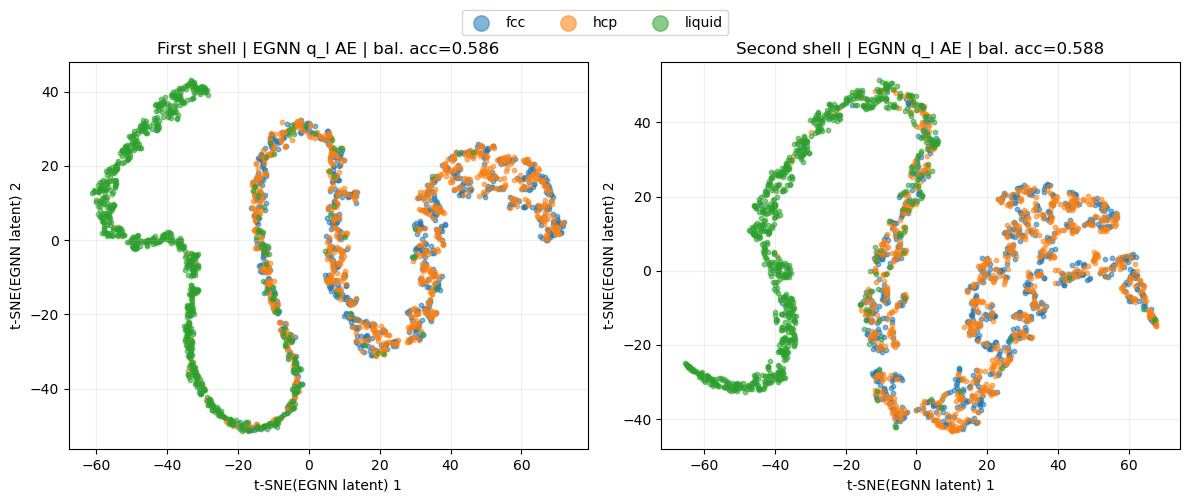

/home/jhausberger/.conda/envs/autoencode-statmech/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/jhausberger/.conda/envs/autoencode-statmech/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


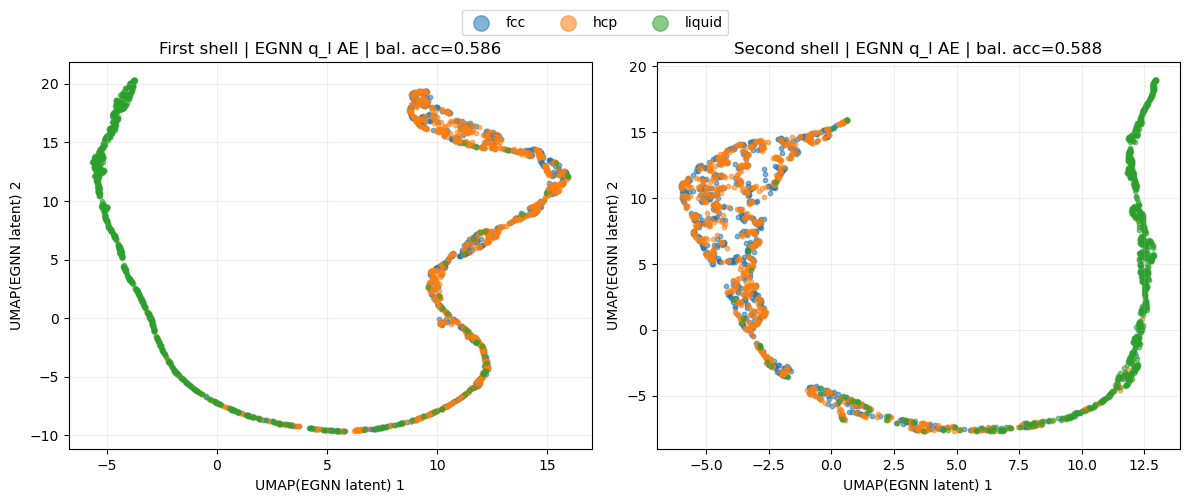

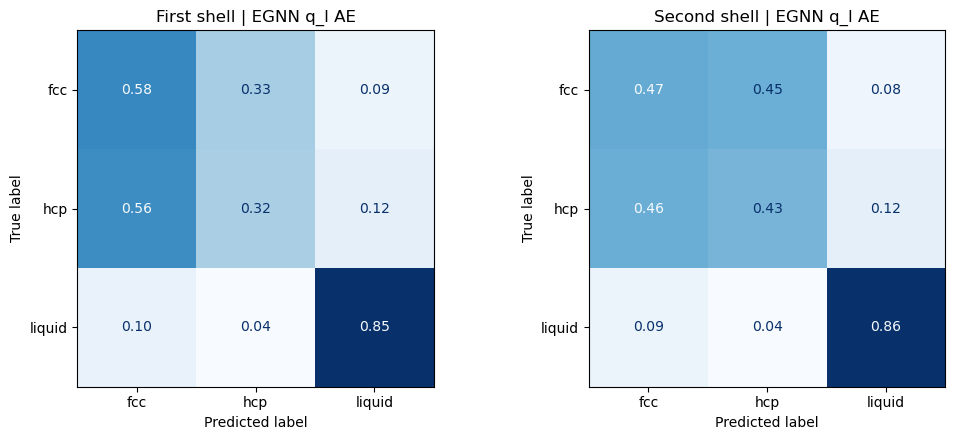

In [ ]:
def plot_egnn_ql_latents(artifacts, method=EGNN_VIS_METHOD):
    fig, axes = plt.subplots(1, len(SHELL_ORDER), figsize=(12, 4.8), squeeze=False)
    for ax, shell_name in zip(axes[0], SHELL_ORDER):
        art = artifacts[shell_name]
        Z_plot, y_plot, projection_label = project_egnn_latent_for_plot(art["Z"], art["y"], method=method)
        for phase in PHASES:
            lab = LABEL_MAP[phase]
            mask = y_plot == lab
            ax.scatter(
                Z_plot[mask, 0],
                Z_plot[mask, 1],
                s=SCATTER_S,
                alpha=SCATTER_ALPHA,
                color=LABEL_COLORS[lab],
                label=phase,
            )
        score = art["scores"]["balanced_accuracy"]
        ax.set_title(f"{SHELL_LABELS[shell_name]} | EGNN q_l AE | bal. acc={score:.3f}")
        ax.set_xlabel(projection_label + " 1")
        ax.set_ylabel(projection_label + " 2")
        ax.grid(alpha=0.2)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=len(PHASES),
        bbox_to_anchor=(0.5, 1.05),
        markerscale=LEGEND_MARKERSCALE,
        fontsize=LEGEND_FONTSIZE,
    )
    plt.tight_layout()
    plt.show()


def plot_egnn_ql_confusions(artifacts, normalize="true"):
    fig, axes = plt.subplots(1, len(SHELL_ORDER), figsize=(10.5, 4.5), squeeze=False)
    for ax, shell_name in zip(axes[0], SHELL_ORDER):
        scores = artifacts[shell_name]["scores"]
        names = [LABEL_NAMES[i] for i in scores["labels"]]
        cm = confusion_matrix(
            scores["y_test"],
            scores["y_pred"],
            labels=scores["labels"],
            normalize=normalize,
        )
        disp = ConfusionMatrixDisplay(cm, display_labels=names)
        disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
        ax.set_title(f"{SHELL_LABELS[shell_name]} | EGNN q_l AE")
        ax.grid(False)
    plt.tight_layout()
    plt.show()

if not SKIP_EGNN_QL:
    plot_egnn_ql_latents(egnn_ql_artifacts, method=EGNN_VIS_METHOD)
    if globals().get("UMAP_AVAILABLE", False):
        plot_egnn_ql_latents(egnn_ql_artifacts, method="umap")
    plot_egnn_ql_confusions(egnn_ql_artifacts, normalize="true")


## 13) q_l-target EGNN delta and training curves

,delta_latent_accuracy,delta_latent_balanced_accuracy,delta_latent_macro_f1,delta_final_val_loss
0,0.0017,0.0017,0.0082,0.0003


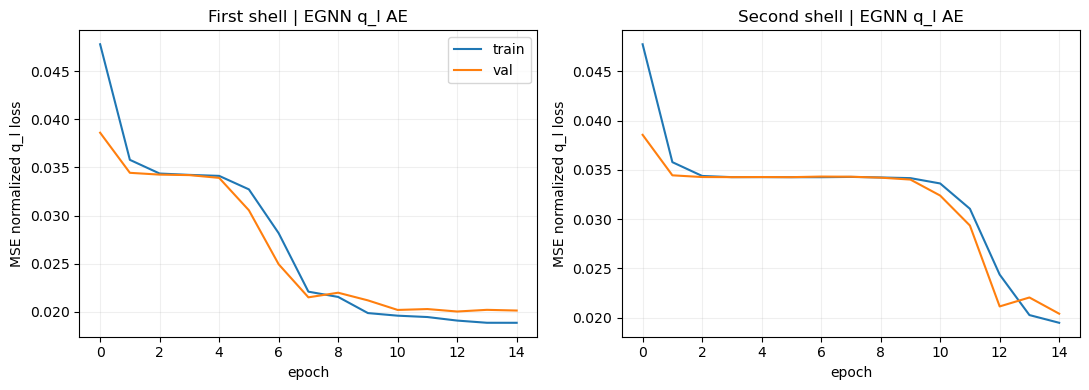

In [ ]:
if not SKIP_EGNN_QL:
    egnn_ql_metric_cols = ["latent_accuracy", "latent_balanced_accuracy", "latent_macro_f1", "final_val_loss"]
    egnn_ql_wide = egnn_ql_scores_df.set_index("shell")[egnn_ql_metric_cols]
    egnn_ql_delta = {
        f"delta_{metric}": egnn_ql_wide.loc["second_shell", metric] - egnn_ql_wide.loc["first_shell", metric]
        for metric in egnn_ql_metric_cols
    }
    display(pd.DataFrame([egnn_ql_delta]).round(4))

    fig, axes = plt.subplots(1, len(SHELL_ORDER), figsize=(11, 4), squeeze=False)
    for ax, shell_name in zip(axes[0], SHELL_ORDER):
        hist = egnn_ql_artifacts[shell_name]["history"]
        ax.plot(hist["loss"], label="train")
        ax.plot(hist["val_loss"], label="val")
        ax.set_title(f"{SHELL_LABELS[shell_name]} | EGNN q_l AE")
        ax.set_xlabel("epoch")
        ax.set_ylabel("MSE normalized q_l loss")
        ax.grid(alpha=0.2)
    axes[0, 0].legend()
    plt.tight_layout()
    plt.show()
